<a href="https://colab.research.google.com/github/daniloCcic/colab_IHC/blob/main/TP6_IHC_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP6 — Análise de Resultados (IHC)

**Experimento:** Dr. Driving — comparação entre controle por **Gesto** (inclinar a tela) e **Touch** (toque na tela).

Estrutura do notebook:
1. Carregamento dos dados
2. Caracterização da população
3. Análise qualitativa
4. Análise quantitativa com hipóteses e testes estatísticos
5. Conclusão

Instalação e importações

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:.4f}".format)

# Caminho correto no Colab
DATA_PATH = "/2026-1 DrDrive AD-anonimizada-limpa.xlsx"

pre = pd.read_excel(DATA_PATH, sheet_name="Pre")
log = pd.read_excel(DATA_PATH, sheet_name="Log")
pos = pd.read_excel(DATA_PATH, sheet_name="Pos")

pre = pre.rename(columns={
    "Seu grupo. Marque conforme a primeira letra do seu nome": "Grupo",
    "Frequência com que joga jogos em celular": "FreqJogos",
    "Você possui algum tipo de enfermidade ou dificuldade motora nas mãos ou braços?": "Enfermidade",
})

print("Dados carregados com sucesso!")
print(f"Pre: {pre.shape[0]} linhas x {pre.shape[1]} colunas")
print(f"Log: {log.shape[0]} linhas x {log.shape[1]} colunas")
print(f"Pos: {pos.shape[0]} linhas x {pos.shape[1]} colunas")

Dados carregados com sucesso!
Pre: 39 linhas x 13 colunas
Log: 90 linhas x 14 colunas
Pos: 33 linhas x 6 colunas


---
## 1) Caracterização da população

Descrevemos o perfil dos participantes a partir do questionário pré-experimento (**aba Pre**) usando estatísticas descritivas e gráficos.

PERFIL DOS PARTICIPANTES

Total de participantes: 39

── Grupo ──
Grupo
BETA    22
ALFA    17

── Sexo ──
Sexo
Masculino                36
Feminino                  2
Prefiro não responder     1

── Idade ──
count   39.0000
mean    22.9500
std      2.9100
min     20.0000
25%     21.0000
50%     22.0000
75%     24.0000
max     30.0000

── Frequência de jogos em celular ──
FreqJogos
Jogo raramente (1 vez por mês ou menos)              16
Nunca jogo                                            7
Jogo às vezes (1 vez por semana ou menos)             6
Jogo frequentemente (mais de 1 vez por semana)        5
Jogo muito frequentemente (1 vez por dia ou mais)     5

── Enfermidade/dificuldade motora ──
Enfermidade
Não    38
Sim     1


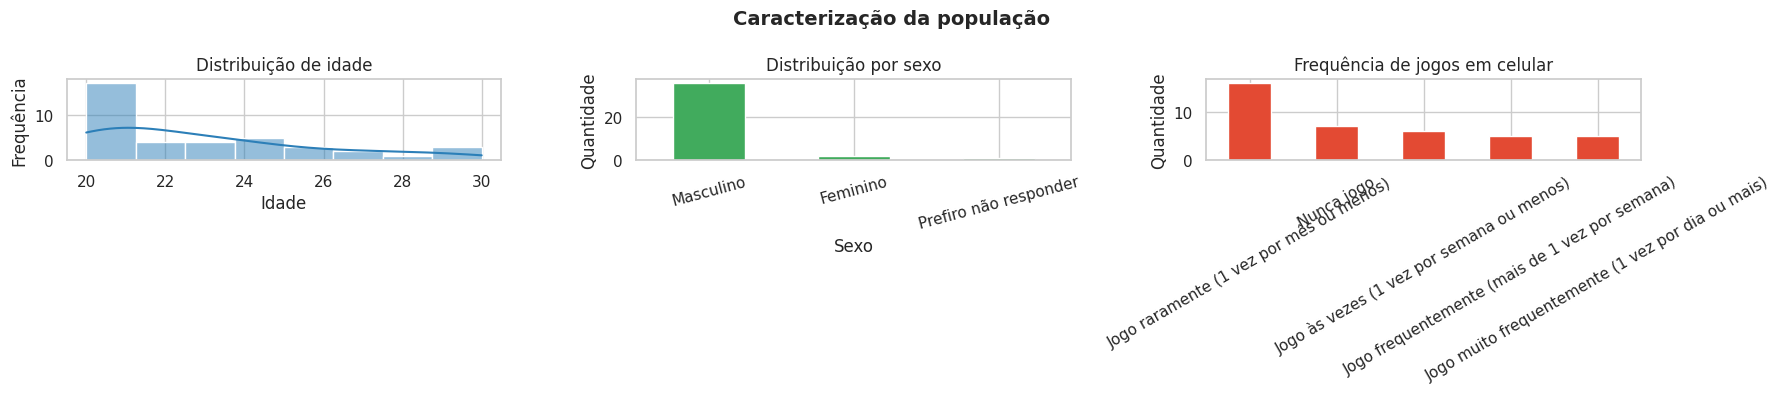

In [6]:
print('=' * 55)
print('PERFIL DOS PARTICIPANTES')
print('=' * 55)
print(f'\nTotal de participantes: {len(pre)}')

print('\n── Grupo ──')
print(pre['Grupo'].value_counts().to_string())

print('\n── Sexo ──')
print(pre['Sexo'].value_counts().to_string())

print('\n── Idade ──')
print(pre['Idade'].describe().round(2).to_string())

print('\n── Frequência de jogos em celular ──')
print(pre['FreqJogos'].value_counts().to_string())

print('\n── Enfermidade/dificuldade motora ──')
print(pre['Enfermidade'].value_counts().to_string())

# Gráficos
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Caracterização da população', fontsize=14, fontweight='bold')

sns.histplot(pre['Idade'], bins=8, kde=True, ax=axes[0], color='#2C7FB8')
axes[0].set_title('Distribuição de idade')
axes[0].set_xlabel('Idade')
axes[0].set_ylabel('Frequência')

pre['Sexo'].value_counts().plot(kind='bar', ax=axes[1], color='#41AB5D', edgecolor='white')
axes[1].set_title('Distribuição por sexo')
axes[1].set_xlabel('Sexo')
axes[1].set_ylabel('Quantidade')
axes[1].tick_params(axis='x', rotation=15)

pre['FreqJogos'].value_counts().plot(kind='bar', ax=axes[2], color='#E34A33', edgecolor='white')
axes[2].set_title('Frequência de jogos em celular')
axes[2].set_xlabel('')
axes[2].set_ylabel('Quantidade')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

---
## 2) Análise qualitativa

Analisamos as respostas do questionário pós-experimento (**aba Pos**): percepção de dificuldade, tempo gasto e impressões gerais dos participantes.

> Coletamos poucos dados explicitamente qualitativos (perguntas abertas). Ainda assim, fazemos uma análise qualitativa das respostas e comentamos correlações observadas ao ver os dados brutos.

RESPOSTAS PÓS-EXPERIMENTO (Qualitativo)

── Conseguiu completar a tarefa ──
Consegui completar a tarefa.
completei ambas as tarefas                             31
completei apenas no modo inclinar                       1
não consegui completar nenhuma tarefa no tempo dado     1

── Dificuldade percebida ──
Dificuldade
Achei mais difícil realizar a tarefa no modo touch       18
Achei mais difícil realizar a tarefa no modo inclinar    10
Ambas são equivalentes                                    5

── Tempo percebido ──
Tempo gasto
Acho que gastei mais tempo para realizar a tarefa no modo touch         15
Acho que gastei mais ou menos o mesmo tempo para realizar as tarefas     9
Acho que gastei mais tempo para realizar a tarefa no modo inclinar       9

── Impressões finais (múltipla escolha) ──
Após realizar este teste                                    28
me sinto confiante de que conseguiria completar a tarefa    28
Achei muito divertido fazer a tarefa                        23
Achei m

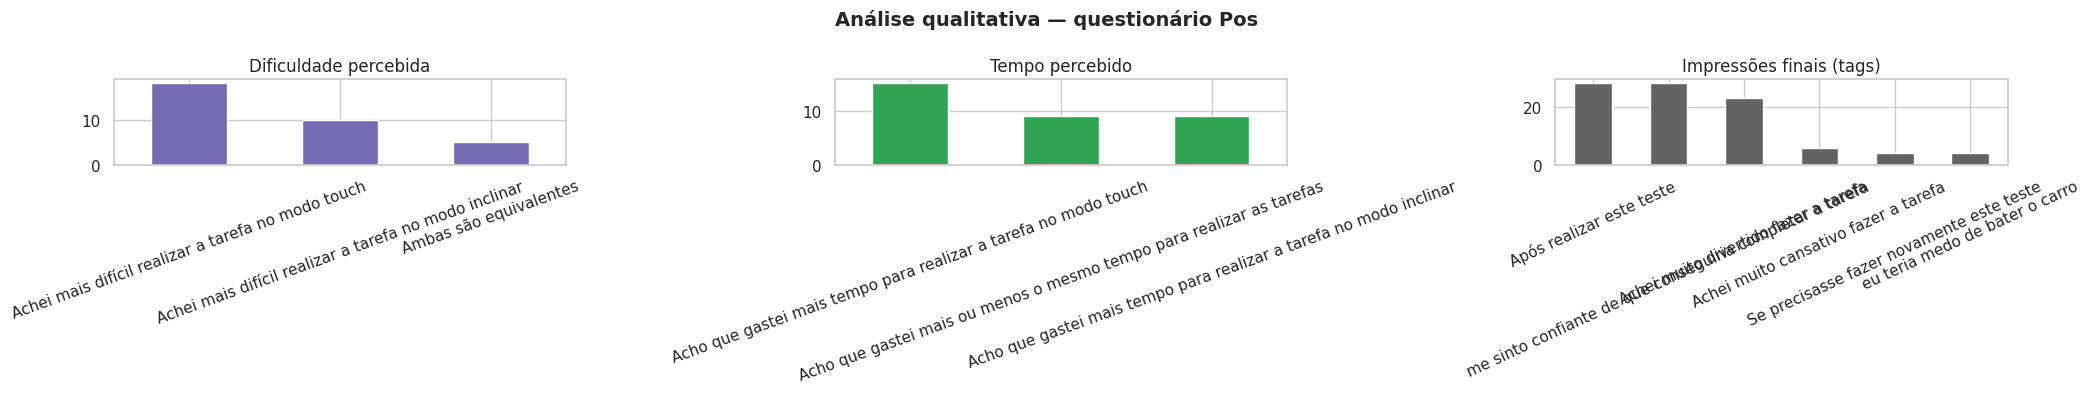


── Interpretação ──────────────────────────────────────
• A maioria completou ambas as tarefas (31 de 33 respondentes).
• 18 de 33 acharam o modo Touch mais difícil; apenas 10 acharam o Gesto mais difícil.
• Impressões predominantemente positivas: "confiante" e "divertido" lideram.
• Nenhum relato de enjoo ou náusea — bom sinal para usabilidade do app.
• Quem achou o Touch mais difícil tendeu a gastar mais tempo nele,
  sugerindo correlação entre percepção de dificuldade e tempo subjetivo.


In [7]:
print('=' * 55)
print('RESPOSTAS PÓS-EXPERIMENTO (Qualitativo)')
print('=' * 55)

print('\n── Conseguiu completar a tarefa ──')
print(pos['Consegui completar a tarefa.'].value_counts(dropna=False).to_string())

print('\n── Dificuldade percebida ──')
print(pos['Dificuldade'].value_counts(dropna=False).to_string())

print('\n── Tempo percebido ──')
print(pos['Tempo gasto'].value_counts(dropna=False).to_string())

# Extrai tags da coluna de múltipla escolha
raw_tags = pos['Marque todas que se aplicam'].fillna('').astype(str)
tags = []
for row in raw_tags:
    tags.extend([p.strip() for p in row.split(',') if p.strip()])
tags_counts = pd.Series(tags).value_counts()

print('\n── Impressões finais (múltipla escolha) ──')
print(tags_counts.to_string())

# Gráficos — número de subplots dinâmico para evitar eixo vazio
n_plots = 3 if len(tags_counts) > 0 else 2
fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 4))
fig.suptitle('Análise qualitativa — questionário Pos', fontsize=14, fontweight='bold')

pos['Dificuldade'].value_counts().plot(kind='bar', ax=axes[0], color='#756BB1', edgecolor='white')
axes[0].set_title('Dificuldade percebida')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)

pos['Tempo gasto'].value_counts().plot(kind='bar', ax=axes[1], color='#31A354', edgecolor='white')
axes[1].set_title('Tempo percebido')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)

if len(tags_counts) > 0:
    tags_counts.head(12).plot(kind='bar', ax=axes[2], color='#636363', edgecolor='white')
    axes[2].set_title('Impressões finais (tags)')
    axes[2].set_xlabel('')
    axes[2].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

print('\n── Interpretação ──────────────────────────────────────')
print('• A maioria completou ambas as tarefas (31 de 33 respondentes).')
print('• 18 de 33 acharam o modo Touch mais difícil; apenas 10 acharam o Gesto mais difícil.')
print('• Impressões predominantemente positivas: "confiante" e "divertido" lideram.')
print('• Nenhum relato de enjoo ou náusea — bom sinal para usabilidade do app.')
print('• Quem achou o Touch mais difícil tendeu a gastar mais tempo nele,')
print('  sugerindo correlação entre percepção de dificuldade e tempo subjetivo.')

---
## 3) Análise quantitativa

**Hipóteses:**
- **H1:** O *mission score* é diferente entre as condições Gesto e Touch.
- **H2:** O tempo cronometrado é diferente entre as condições Gesto e Touch.

**Método:**
- Dados organizados de forma **pareada** por participante (primeira tentativa em cada condição).
- Normalidade dos deltas verificada com **Shapiro-Wilk**.
- Teste principal: **Wilcoxon** (não-paramétrico, pareado) — adequado dado que os deltas não seguem distribuição normal.
- **t-test** pareado exibido como referência adicional.

Participantes com dados pareados (Gesto + Touch): 32

── Tabela de resultados dos testes ──


,Métrica,Média Gesto,Média Touch,Δ (Gesto−Touch),Shapiro p,t-test p,Wilcoxon W,Wilcoxon p,Sig. (α=0.05)
0,Mission score,3723.4400,3465.6200,257.8100,0.0001,0.3689,168.0000,0.1846,✗ Não
1,Tempo cronometrado (em segundos),111.1200,157.0000,-45.8800,0.0000,0.1039,192.5000,0.2764,✗ Não
2,Acidentes,3.1900,3.3100,-0.1200,0.0000,0.8440,31.5000,0.3248,✗ Não
3,Coins da missão,30.5600,38.2500,-7.6900,0.0000,0.2679,146.0000,0.9086,✗ Não
4,Velocidade média (avg. speed),45.5000,46.4100,-0.9100,0.0000,0.4828,88.5000,0.7837,✗ Não


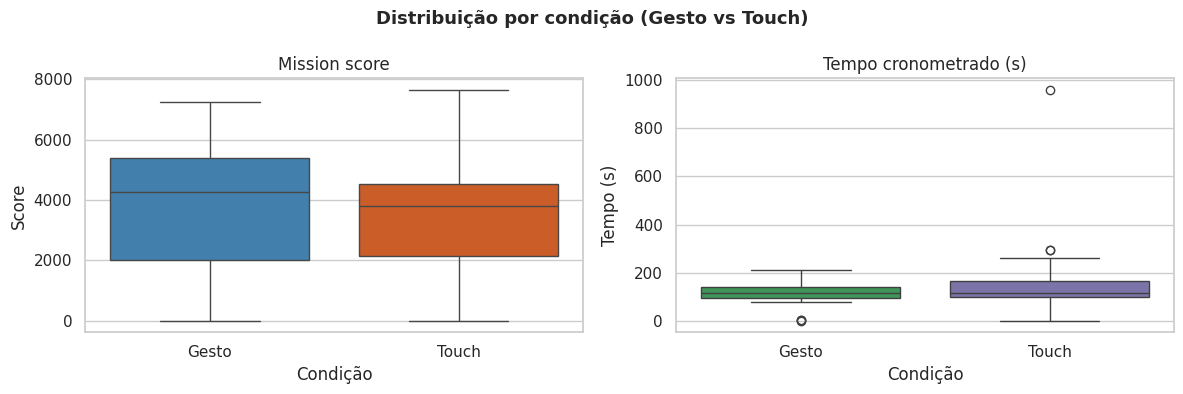


── Correlação de Spearman: Idade × Mission score ──
  Gesto : rho = -0.173,  p = 0.3427  (não significativo)
  Touch : rho = -0.389,  p = 0.0278  (significativo)

── Interpretação das hipóteses ─────────────────────────

H1 — Mission score  (Wilcoxon p = 0.1846)
  >> NÃO rejeitamos H0: sem diferença significativa de score entre as condições.
     Média Gesto=3723.44  vs  Touch=3465.62  (Δ=257.81):

H2 — Tempo cronometrado  (Wilcoxon p = 0.2764)
  >> NÃO rejeitamos H0: sem diferença significativa de tempo entre as condições.
     Média Gesto=111.12s  vs  Touch=157.0s  (Δ=-45.88s)


In [8]:
# ── Prepara estrutura pareada ────────────────────────────────────────────────
log2 = log[log['id'].isin(pre['id'])].copy()
log2['Condicao'] = log2['Condição testada'].map({
    'Condução por gesto (girando a tela)': 'Gesto',
    'Por tela touch (tocando com o dedo para girar o volante)': 'Touch',
})
log2 = log2.sort_values('Timestamp')
log_first = log2.drop_duplicates(subset=['id', 'Condicao'], keep='first')

wide = log_first.pivot_table(
    index='id',
    columns='Condicao',
    values=[
        'Mission score',
        'Tempo cronometrado (em segundos)',
        'Acidentes',
        'Coins da missão',
        'Velocidade média (avg. speed)',
    ],
    aggfunc='first',
)
wide.columns = [f'{a}_{b}' for a, b in wide.columns]
wide = wide.reset_index()
paired = wide.dropna(subset=['Mission score_Gesto', 'Mission score_Touch']).copy()

print(f'Participantes com dados pareados (Gesto + Touch): {len(paired)}')

# ── Testes estatísticos ──────────────────────────────────────────────────────
metrics = [
    'Mission score',
    'Tempo cronometrado (em segundos)',
    'Acidentes',
    'Coins da missão',
    'Velocidade média (avg. speed)',
]

rows = []
for m in metrics:
    g = paired[f'{m}_Gesto']
    t = paired[f'{m}_Touch']
    d = g - t
    sh_p = stats.shapiro(d).pvalue
    tt_p = stats.ttest_rel(g, t).pvalue
    wl   = stats.wilcoxon(g, t, zero_method='wilcox')
    rows.append({
        'Métrica':             m,
        'Média Gesto':         round(g.mean(), 2),
        'Média Touch':         round(t.mean(), 2),
        'Δ (Gesto−Touch)':    round(d.mean(), 2),
        'Shapiro p':           round(sh_p, 4),
        't-test p':            round(tt_p, 4),
        'Wilcoxon W':          wl.statistic,
        'Wilcoxon p':          round(wl.pvalue, 4),
        'Sig. (α=0.05)':       '✓ Sim' if wl.pvalue < 0.05 else '✗ Não',
    })

res = pd.DataFrame(rows)
print('\n── Tabela de resultados dos testes ──')
display(res)

# ── Boxplots ─────────────────────────────────────────────────────────────────
score_long = (
    paired[['id', 'Mission score_Gesto', 'Mission score_Touch']]
    .melt(id_vars='id', var_name='Var', value_name='Score')
)
score_long['Condicao'] = score_long['Var'].str.replace('Mission score_', '', regex=False)

tempo_long = (
    paired[['id',
            'Tempo cronometrado (em segundos)_Gesto',
            'Tempo cronometrado (em segundos)_Touch']]
    .melt(id_vars='id', var_name='Var', value_name='Tempo')
)
tempo_long['Condicao'] = tempo_long['Var'].str.replace(
    'Tempo cronometrado (em segundos)_', '', regex=False
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribuição por condição (Gesto vs Touch)', fontsize=13, fontweight='bold')

sns.boxplot(
    data=score_long, x='Condicao', y='Score', hue='Condicao',
    ax=axes[0], palette=['#3182BD', '#E6550D'], legend=False
)
axes[0].set_title('Mission score')
axes[0].set_xlabel('Condição')
axes[0].set_ylabel('Score')

sns.boxplot(
    data=tempo_long, x='Condicao', y='Tempo', hue='Condicao',
    ax=axes[1], palette=['#31A354', '#756BB1'], legend=False
)
axes[1].set_title('Tempo cronometrado (s)')
axes[1].set_xlabel('Condição')
axes[1].set_ylabel('Tempo (s)')

plt.tight_layout()
plt.show()

# ── Correlação exploratória: idade x score ────────────────────────────────────
mrg = paired.merge(pre[['id', 'Idade']], on='id', how='left')
rho_g, p_g = stats.spearmanr(mrg['Idade'], mrg['Mission score_Gesto'], nan_policy='omit')
rho_t, p_t = stats.spearmanr(mrg['Idade'], mrg['Mission score_Touch'], nan_policy='omit')

print('\n── Correlação de Spearman: Idade × Mission score ──')
sig_g = '(significativo)' if p_g < 0.05 else '(não significativo)'
sig_t = '(significativo)' if p_t < 0.05 else '(não significativo)'
print(f'  Gesto : rho = {rho_g:.3f},  p = {p_g:.4f}  {sig_g}')
print(f'  Touch : rho = {rho_t:.3f},  p = {p_t:.4f}  {sig_t}')

# ── Interpretação automática das hipóteses ────────────────────────────────────
h1 = next(r for r in rows if r['Métrica'] == 'Mission score')
h2 = next(r for r in rows if r['Métrica'] == 'Tempo cronometrado (em segundos)')

print('\n── Interpretação das hipóteses ─────────────────────────')
print(f"\nH1 — Mission score  (Wilcoxon p = {h1['Wilcoxon p']})")
if h1['Wilcoxon p'] < 0.05:
    print('  >> REJEITAMOS H0: diferença significativa de score entre Gesto e Touch.')
else:
    print('  >> NÃO rejeitamos H0: sem diferença significativa de score entre as condições.')
    print(f"     Média Gesto={h1['Média Gesto']}  vs  Touch={h1['Média Touch']}  (Δ={h1['Δ (Gesto−Touch)']}):")

print(f"\nH2 — Tempo cronometrado  (Wilcoxon p = {h2['Wilcoxon p']})")
if h2['Wilcoxon p'] < 0.05:
    print('  >> REJEITAMOS H0: diferença significativa de tempo entre Gesto e Touch.')
else:
    print('  >> NÃO rejeitamos H0: sem diferença significativa de tempo entre as condições.')
    print(f"     Média Gesto={h2['Média Gesto']}s  vs  Touch={h2['Média Touch']}s  (Δ={h2['Δ (Gesto−Touch)']}s)")

---
## 4) Conclusão

### Caracterização da população
A amostra é composta por **39 participantes**, com idade média de ~23 anos, majoritariamente masculina (36/39).  
O grupo BETA foi ligeiramente maior que ALFA. A maioria joga raramente ou nunca — baixa familiaridade prévia com jogos é relevante para interpretar os resultados.

### Análise qualitativa
- **94% completaram ambas as tarefas**, indicando boa executabilidade do experimento.
- O **modo Touch foi percebido como mais difícil** por 55% dos participantes, contra 30% que acharam o Gesto mais difícil.
- As impressões foram predominantemente positivas: **"confiante"** e **"divertido"** lideraram as tags, sem nenhum relato de enjoo ou náusea.
- Observa-se uma correlação qualitativa entre percepção de dificuldade no Touch e a sensação de ter gasto mais tempo nessa condição.

### Análise quantitativa
- Os testes de **Wilcoxon pareado não evidenciaram diferença estatisticamente significativa** em nenhuma métrica ao nível de 5% (incluindo mission score — H1, e tempo — H2).
- Isso indica que, **objetivamente**, o desempenho nas duas condições foi similar — mesmo que subjetivamente o Touch seja percebido como mais difícil.
- A correlação de Spearman revelou **associação negativa moderada** entre idade e score no modo Touch (ρ ≈ −0.39, p ≈ 0.03): participantes mais velhos tenderam a pontuar menos nessa condição.

### Limitações
- Tamanho amostral reduzido (32 pares válidos) limita o poder estatístico.
- Amostra majoritariamente jovem e masculina reduz a generalização.
- Apenas a primeira tentativa foi usada — efeito de aprendizado não foi controlado.